In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
Superstore_sales = pd.read_csv('/content/drive/MyDrive/My Projects Dataset/Sample - Superstore.csv', encoding='windows-1252')

In [20]:
Superstore_sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
# Removes rows that are exact copies
Superstore_sales.drop_duplicates(inplace=True)

In [22]:
# Removes rows where data (like Postal Code) is missing
Superstore_sales.dropna(inplace=True)

In [23]:
# Converts string dates to Python DateTime objects for analysis
Superstore_sales['Order Date'] = pd.to_datetime(Superstore_sales['Order Date'])
Superstore_sales['Ship Date'] = pd.to_datetime(Superstore_sales['Ship Date'])

In [24]:
# 'Row ID' is just a database index, not useful for business insights
if 'Row ID' in Superstore_sales.columns:
    Superstore_sales.drop(columns=['Row ID'], inplace=True)

In [25]:
# Extracting Month and Year for Trend Analysis
Superstore_sales['Month_Year'] = Superstore_sales['Order Date'].dt.to_period('M')

In [26]:
# This will show you the clean Non-Null count and correct Data Types
Superstore_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       9994 non-null   object        
 1   Order Date     9994 non-null   datetime64[ns]
 2   Ship Date      9994 non-null   datetime64[ns]
 3   Ship Mode      9994 non-null   object        
 4   Customer ID    9994 non-null   object        
 5   Customer Name  9994 non-null   object        
 6   Segment        9994 non-null   object        
 7   Country        9994 non-null   object        
 8   City           9994 non-null   object        
 9   State          9994 non-null   object        
 10  Postal Code    9994 non-null   int64         
 11  Region         9994 non-null   object        
 12  Product ID     9994 non-null   object        
 13  Category       9994 non-null   object        
 14  Sub-Category   9994 non-null   object        
 15  Product Name   9994 n

In [30]:
# --- FINANCIAL KPI ANALYSIS ---
# Objective: Calculate Actual Profit, Total Loss Incurred, and Potential Profit.

# 1. Splitting transactions into Profitable and Loss-making
profitable_orders = Superstore_sales[Superstore_sales['Profit'] > 0]
loss_making_orders = Superstore_sales[Superstore_sales['Profit'] < 0]

# 2. Calculating Metrics
actual_profit = Superstore_sales['Profit'].sum()
total_loss = loss_making_orders['Profit'].abs().sum()
potential_profit = profitable_orders['Profit'].sum()

# 3. Displaying Results
print(f"💰 Actual Net Profit:      ${actual_profit:,.2f}")
print(f"🔴 Total Loss Incurred:    ${total_loss:,.2f}")
print(f"🚀 Potential Profit:      ${potential_profit:,.2f} (If losses were avoided)")
print(f"📊 Loss Leakage Ratio:    {(total_loss/potential_profit)*100:.2f}%")

💰 Actual Net Profit:      $286,397.02
🔴 Total Loss Incurred:    $156,131.29
🚀 Potential Profit:      $442,528.31 (If losses were avoided)
📊 Loss Leakage Ratio:    35.28%


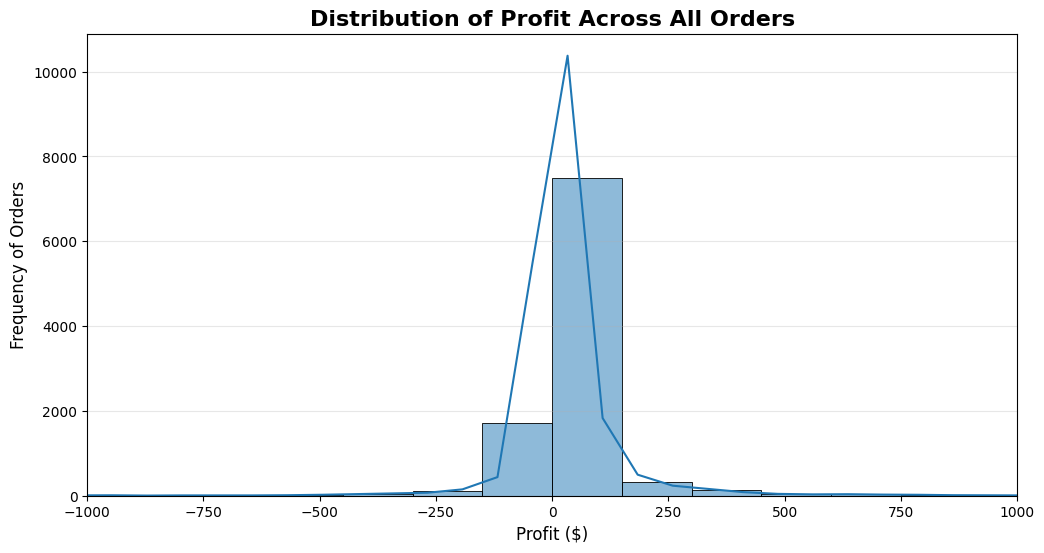

In [41]:
# --- CHART 1: UNIVARIATE ANALYSIS - DISTRIBUTION OF PROFIT ---
# Objective: Analyze the frequency and spread of profit values to identify skewness and outliers.

plt.figure(figsize=(12, 6))
sns.histplot(Superstore_sales['Profit'], bins=100, color='#1f77b4', kde=True)

plt.title('Distribution of Profit Across All Orders', fontsize=16, fontweight='bold')
plt.xlabel('Profit ($)', fontsize=12)
plt.ylabel('Frequency of Orders', fontsize=12)
plt.xlim(-1000, 1000) # Centering on the most common profit range for better visibility
plt.grid(axis='y', alpha=0.3)
plt.show()

# Insight: The distribution shows a high concentration around zero, with a significant 'left tail' representing heavy losses.

/tmp/ipython-input-80261325.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=shipping_counts.index, y=shipping_counts.values, palette='Blues_d')


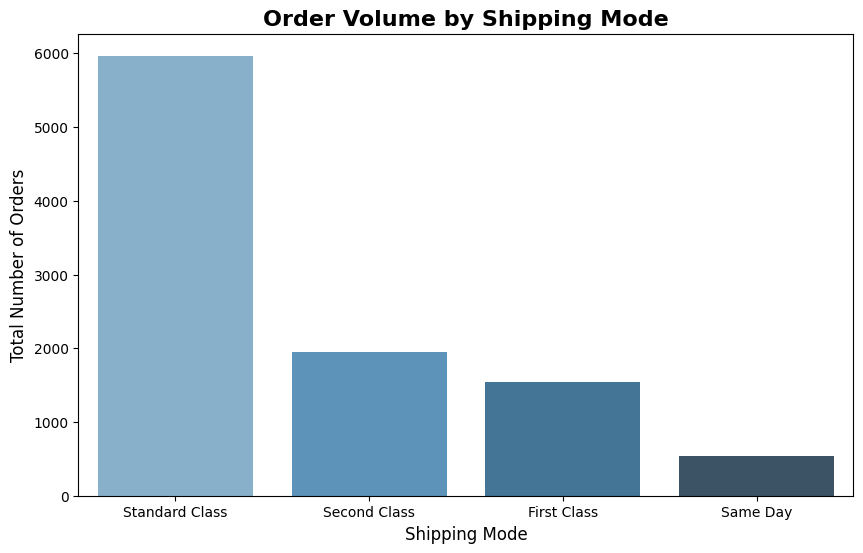

In [42]:
# --- CHART 2: UNIVARIATE ANALYSIS - SHIPPING MODE PREFERENCE ---
# Objective: Understand customer preference for shipping speeds to optimize logistics.

plt.figure(figsize=(10, 6))
# Order by count for a cleaner visual
shipping_counts = Superstore_sales['Ship Mode'].value_counts()
sns.barplot(x=shipping_counts.index, y=shipping_counts.values, palette='Blues_d')

plt.title('Order Volume by Shipping Mode', fontsize=16, fontweight='bold')
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Total Number of Orders', fontsize=12)
plt.show()

# Insight: 'Standard Class' is the dominant choice.
# Business Recommendation: Negotiate better bulk rates for Standard Class with carriers.

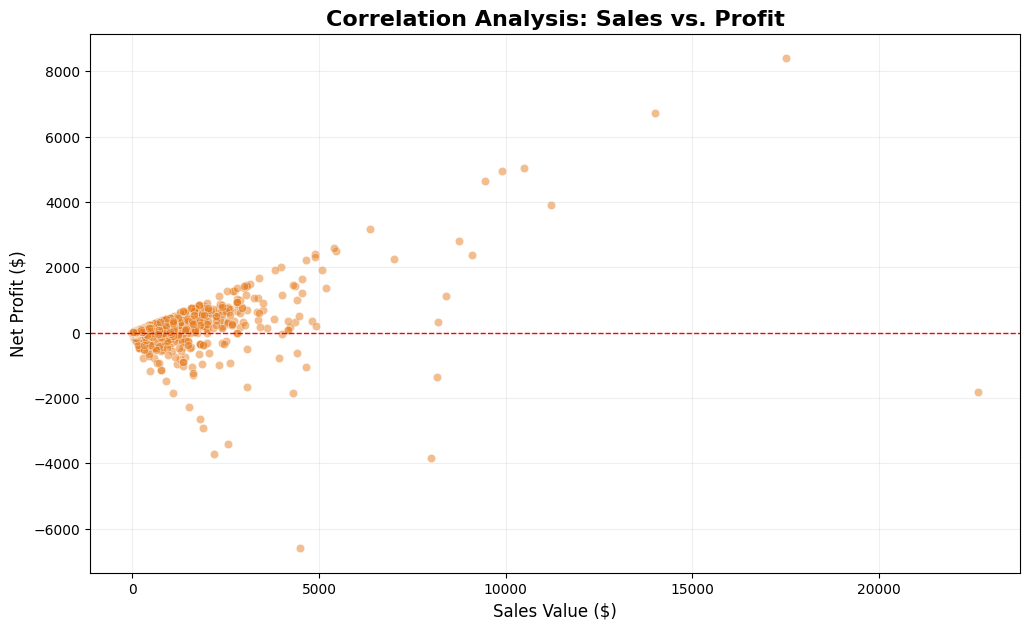

In [43]:
# --- CHART 3: BIVARIATE ANALYSIS - SALES VS. PROFIT SCATTER PLOT ---
# Objective: Identify if higher sales volume consistently leads to higher profit.

plt.figure(figsize=(12, 7))
sns.scatterplot(x='Sales', y='Profit', data=Superstore_sales, alpha=0.5, color='#e67e22')

plt.title('Correlation Analysis: Sales vs. Profit', fontsize=16, fontweight='bold')
plt.xlabel('Sales Value ($)', fontsize=12)
plt.ylabel('Net Profit ($)', fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Line at zero profit
plt.grid(True, alpha=0.2)
plt.show()

# Insight: There is no guaranteed linear relationship.
# Many high-value sales (far right) result in negative profit (below red line), indicating pricing errors.

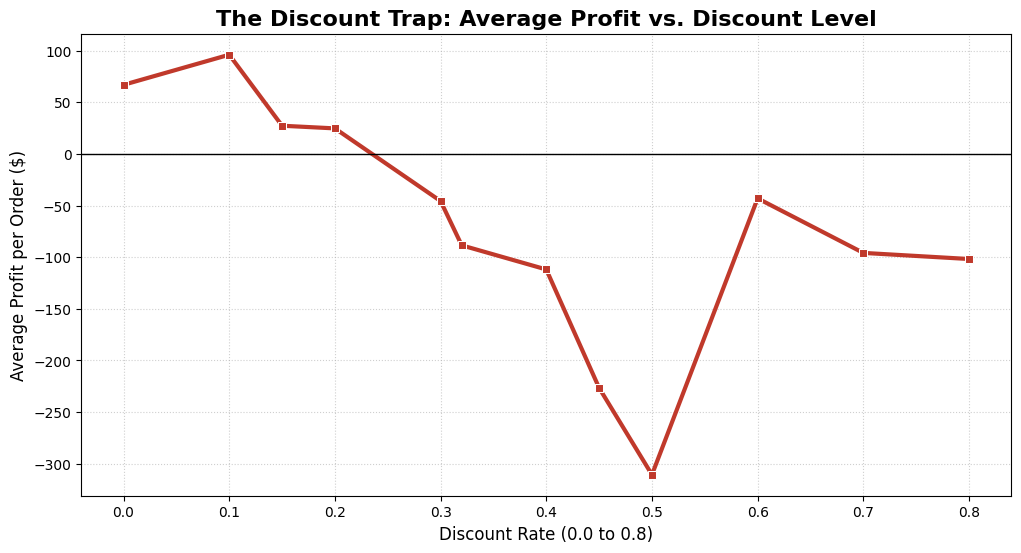

In [44]:
# --- CHART 4: BIVARIATE ANALYSIS - DISCOUNT IMPACT ON PROFIT ---
# Objective: Measure how different discount levels (0% to 80%) affect the average profit per order.

# Grouping by Discount to see Average Profit
discount_impact = Superstore_sales.groupby('Discount')['Profit'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Discount', y='Profit', data=discount_impact, marker='s', color='#c0392b', linewidth=3)

plt.title('The Discount Trap: Average Profit vs. Discount Level', fontsize=16, fontweight='bold')
plt.xlabel('Discount Rate (0.0 to 0.8)', fontsize=12)
plt.ylabel('Average Profit per Order ($)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Insight: Profitability drops below zero once discounts exceed 20%.
# Recommendation: Immediate policy change to cap discounts at 20% for most categories.

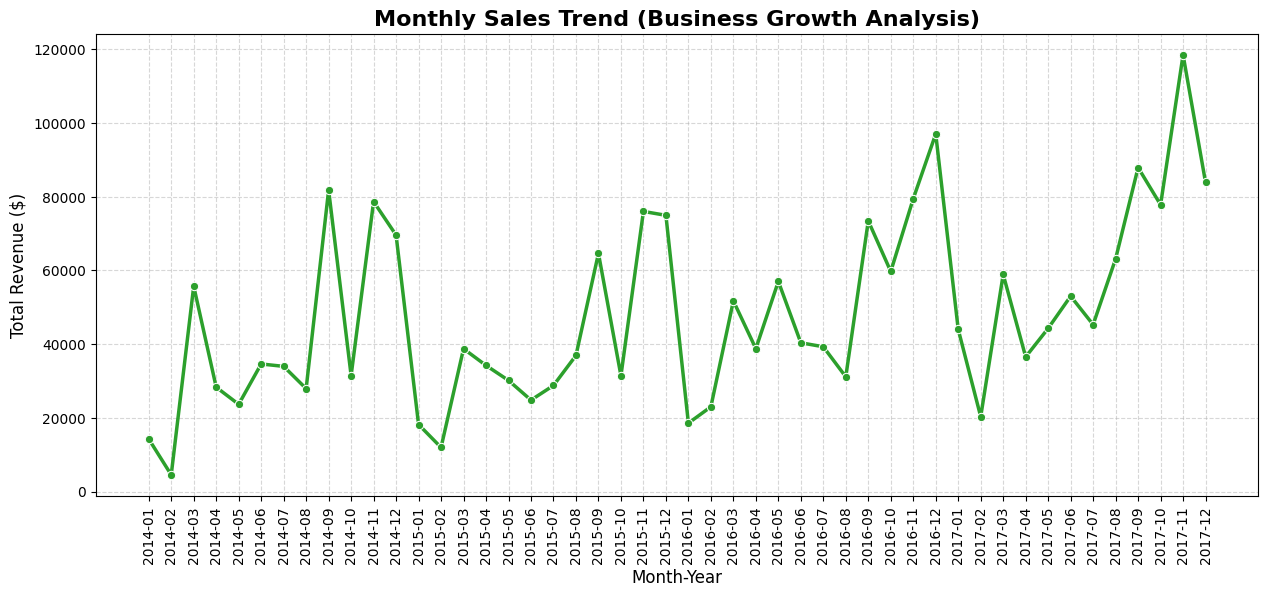

In [31]:
# --- Chart 5: MONTHLY SALES TREND ---
import matplotlib.pyplot as plt
import seaborn as sns

monthly_trend = Superstore_sales.groupby('Month_Year')['Sales'].sum()

plt.figure(figsize=(15, 6))
sns.lineplot(x=monthly_trend.index.astype(str), y=monthly_trend.values, marker='o', color='#2ca02c', linewidth=2.5)

plt.title('Monthly Sales Trend (Business Growth Analysis)', fontsize=16, fontweight='bold')
plt.xlabel('Month-Year', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=90)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

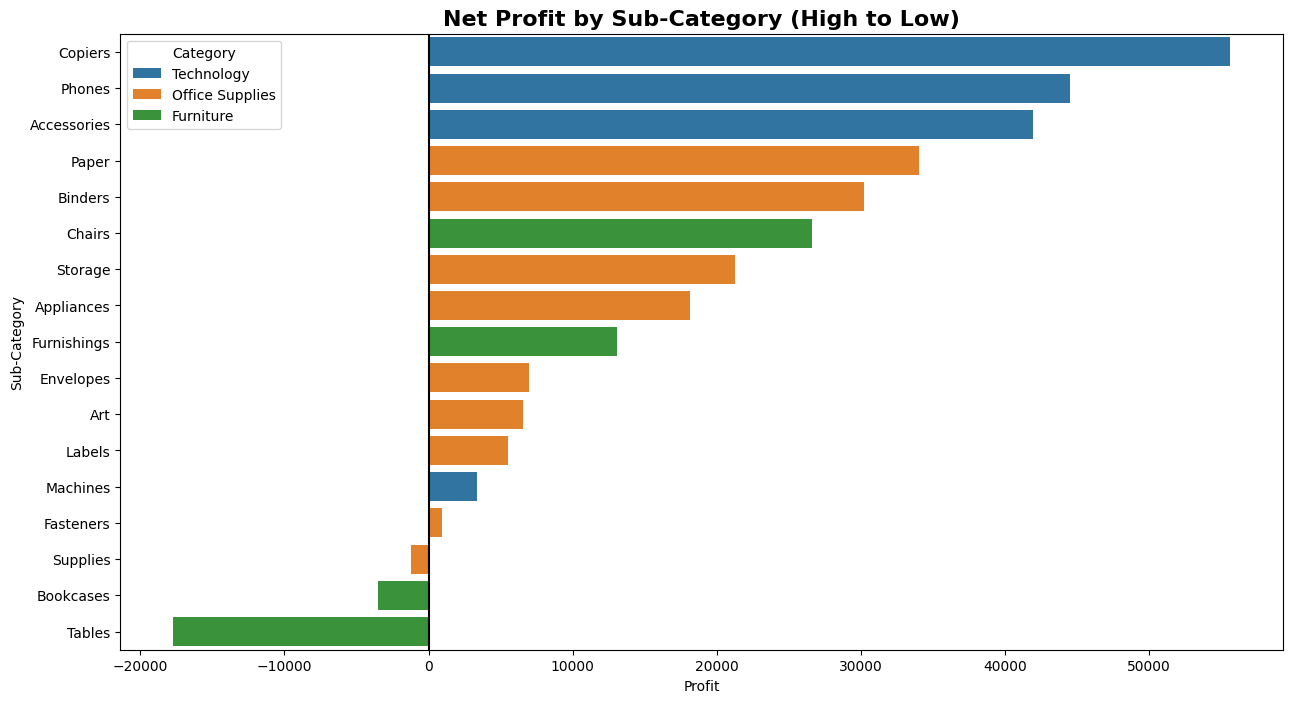

In [32]:
# --- Chart 6: PROFIT BY SUB-CATEGORY ---
# Objective: Identify 'Profit Drainers' vs 'Profit Drivers'.

subcat_profit = Superstore_sales.groupby(['Category', 'Sub-Category'])['Profit'].sum().reset_index().sort_values(by='Profit', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='Profit', y='Sub-Category', hue='Category', data=subcat_profit, dodge=False)

plt.title('Net Profit by Sub-Category (High to Low)', fontsize=16, fontweight='bold')
plt.axvline(x=0, color='black', linewidth=1.5) # Zero line to separate profit and loss
plt.show()

/tmp/ipython-input-2351325886.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  region_analysis = Superstore_sales.groupby('Region').apply(


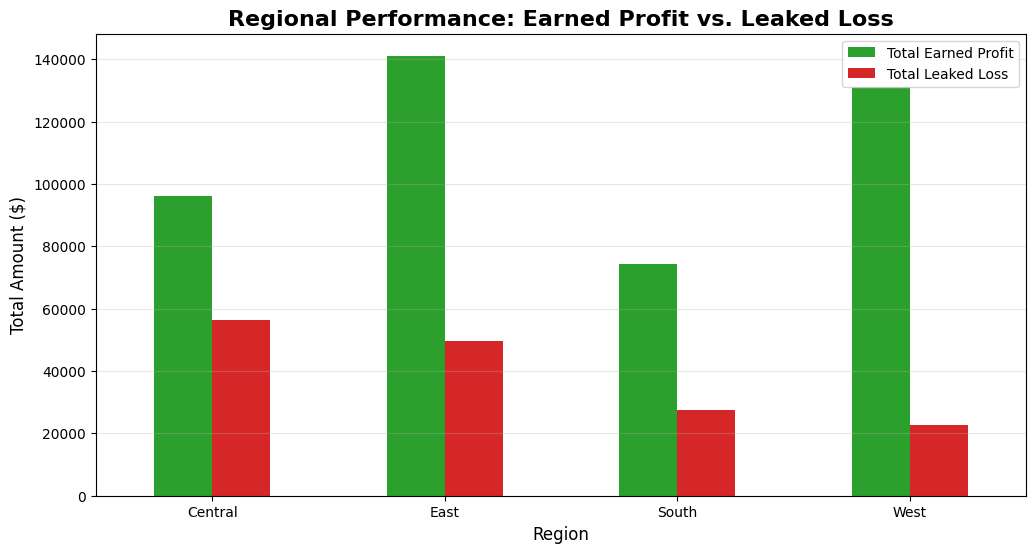

In [38]:
# --- Chart 7: REGIONAL EARNED PROFIT VS. LEAKED LOSS ---
# Objective: Compare the total profit earned against the total loss leaked in each geographic region.

region_analysis = Superstore_sales.groupby('Region').apply(
    lambda x: pd.Series({
        'Earned Profit': x[x['Profit'] > 0]['Profit'].sum(),
        'Leaked Loss': abs(x[x['Profit'] < 0]['Profit'].sum())
    })
).reset_index()

# Plotting the comparison
region_analysis.set_index('Region').plot(kind='bar', figsize=(12, 6), color=['#2ca02c', '#d62728'])

plt.title('Regional Performance: Earned Profit vs. Leaked Loss', fontsize=16, fontweight='bold')
plt.ylabel('Total Amount ($)', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Total Earned Profit', 'Total Leaked Loss'])
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipython-input-2962297887.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=gap_data, palette=['#2ca02c', '#d62728', '#1f77b4'])


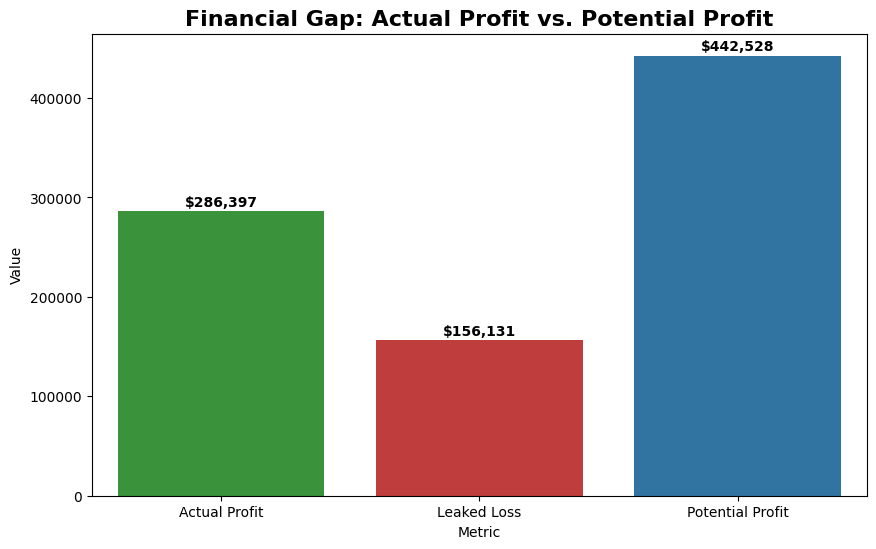

In [36]:
# --- Chart 8: PROFIT GAP ANALYSIS ---
# Objective: Visualize the impact of losses on total potential earnings.

gap_data = pd.DataFrame({
    'Metric': ['Actual Profit', 'Leaked Loss', 'Potential Profit'],
    'Value': [actual_profit, total_loss, potential_profit]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Value', data=gap_data, palette=['#2ca02c', '#d62728', '#1f77b4'])

for i, v in enumerate(gap_data['Value']):
    plt.text(i, v + 5000, f"${v:,.0f}", ha='center', fontweight='bold')

plt.title('Financial Gap: Actual Profit vs. Potential Profit', fontsize=16, fontweight='bold')
plt.show()

/tmp/ipython-input-2066760449.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_breakdown = Superstore_sales.groupby('Category').apply(


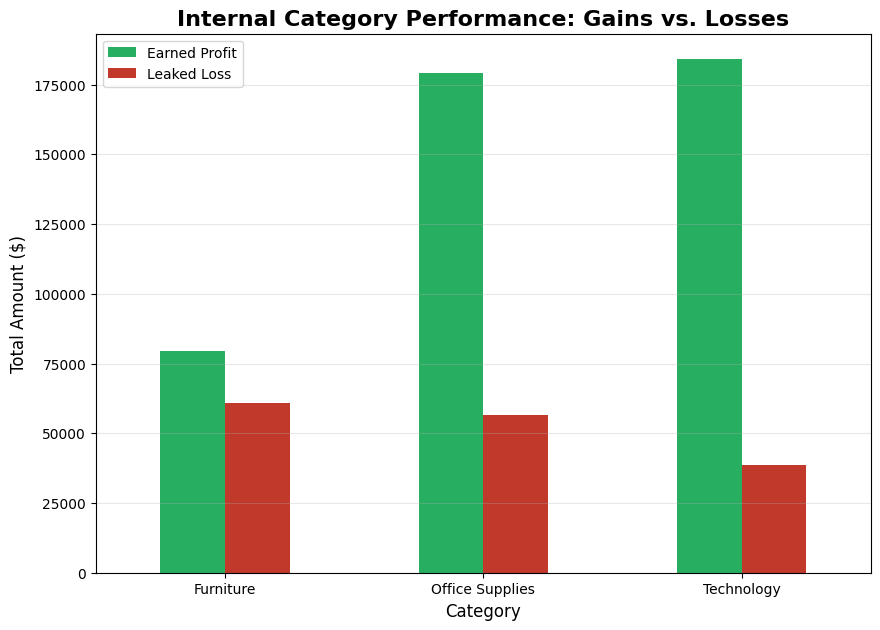

In [39]:
# --- Chart 9: INTERNAL CATEGORY CONFLICT (GAINS VS. LOSSES) ---
# Objective: Identify hidden losses within seemingly profitable product categories.

# Fixed logic: Using Python's built-in abs() for scalar values
cat_breakdown = Superstore_sales.groupby('Category').apply(
    lambda x: pd.Series({
        'Earned Profit': x[x['Profit'] > 0]['Profit'].sum(),
        'Leaked Loss': abs(x[x['Profit'] < 0]['Profit'].sum())
    })
).reset_index()

# Visualizing as a side-by-side comparison
cat_breakdown.set_index('Category').plot(kind='bar', figsize=(10, 7), color=['#27ae60', '#c0392b'])

plt.title('Internal Category Performance: Gains vs. Losses', fontsize=16, fontweight='bold')
plt.ylabel('Total Amount ($)', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipython-input-3299906736.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ship Mode', y='Ship_Lag', data=Superstore_sales, palette='magma', estimator='mean')


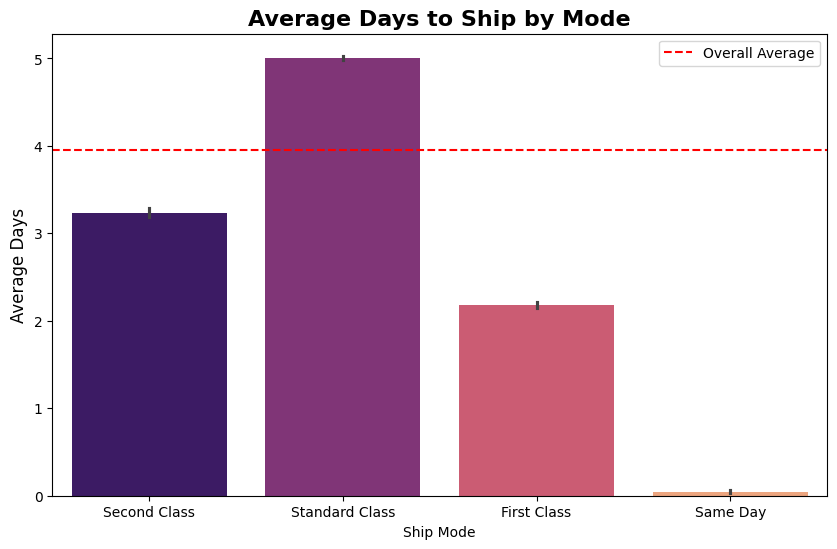

In [46]:
# --- chart 10: SHIPPING EFFICIENCY ANALYSIS ---
# Objective: Measure the time taken to ship orders and identify operational bottlenecks.

# 1. Calculating 'Ship Lag' (Days taken to ship)
Superstore_sales['Ship_Lag'] = (Superstore_sales['Ship Date'] - Superstore_sales['Order Date']).dt.days

# 2. Visualizing Average Ship Lag by Ship Mode
plt.figure(figsize=(10, 6))
sns.barplot(x='Ship Mode', y='Ship_Lag', data=Superstore_sales, palette='magma', estimator='mean')

plt.title('Average Days to Ship by Mode', fontsize=16, fontweight='bold')
plt.ylabel('Average Days', fontsize=12)
plt.axhline(Superstore_sales['Ship_Lag'].mean(), color='red', linestyle='--', label='Overall Average')
plt.legend()
plt.show()

# Insight: If 'Same Day' mode shows more than 0.5 days, there is an operational failure.

In [47]:
# --- PARETO ANALYSIS (80/20 RULE) ---
# Objective: Identify the critical 20% of products that drive 80% of total revenue.

product_revenue = Superstore_sales.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index()
product_revenue['Cum_Sales'] = product_revenue['Sales'].cumsum()
product_revenue['Cum_Percent'] = 100 * product_revenue['Cum_Sales'] / product_revenue['Sales'].sum()

# Finding the point where cumulative sales reach 80%
top_20_cutoff = product_revenue[product_revenue['Cum_Percent'] <= 80].shape[0]
total_products = product_revenue.shape[0]

print(f"📌 Pareto Insight: {top_20_cutoff} products out of {total_products} contribute to 80% of total revenue.")

📌 Pareto Insight: 419 products out of 1850 contribute to 80% of total revenue.


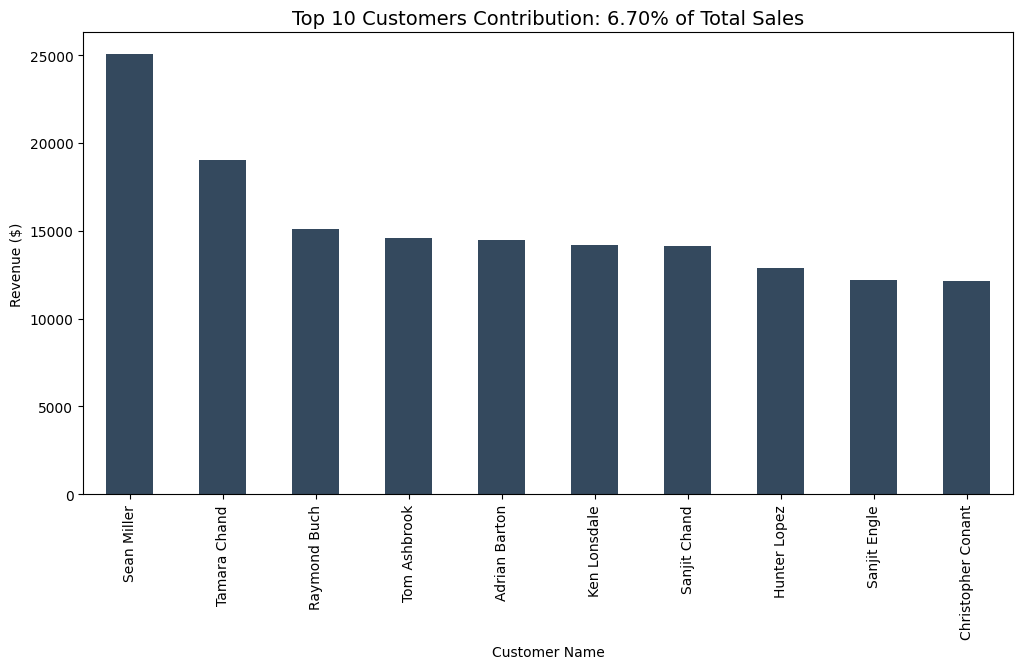

In [49]:
# --- Chart 11: TOP 10 CUSTOMER CONTRIBUTION ---
# Objective: Analyze the revenue share of the top 10 customers.

top_customers = Superstore_sales.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
total_revenue = Superstore_sales['Sales'].sum()
contribution = (top_customers.sum() / total_revenue) * 100

plt.figure(figsize=(12, 6))
top_customers.plot(kind='bar', color='#34495e')
plt.title(f'Top 10 Customers Contribution: {contribution:.2f}% of Total Sales', fontsize=14)
plt.ylabel('Revenue ($)')
plt.show()

/tmp/ipython-input-1068260495.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales_smooth = Superstore_sales.set_index('Order Date').resample('M')['Sales'].sum().to_frame()


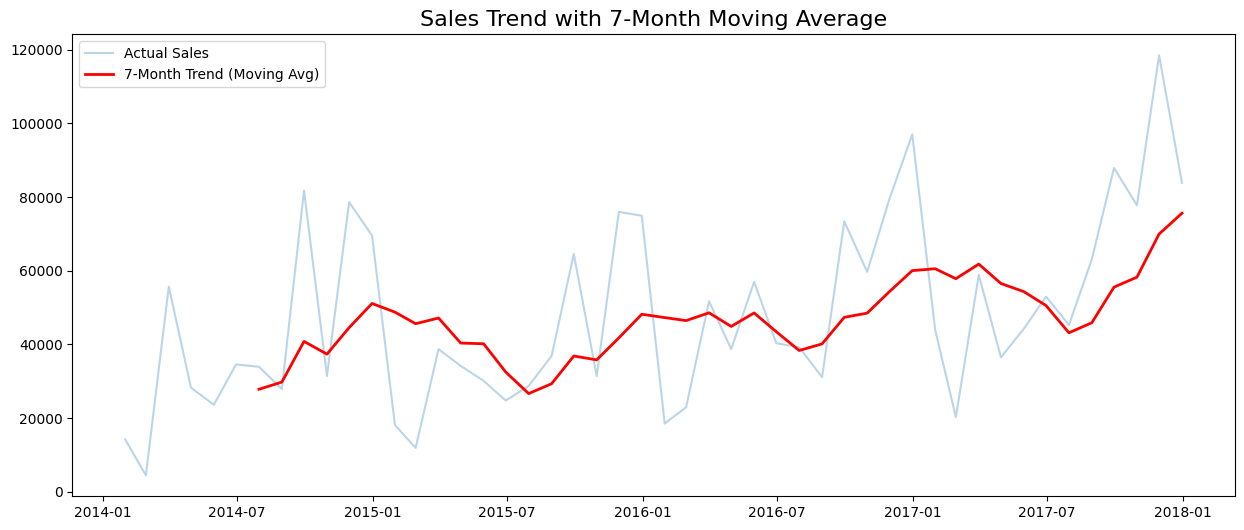

In [50]:
# --- Chart 12: 7-MONTH MOVING AVERAGE ---
# Objective: Smooth out seasonal fluctuations to see the long-term sales trend.

monthly_sales_smooth = Superstore_sales.set_index('Order Date').resample('M')['Sales'].sum().to_frame()
monthly_sales_smooth['Moving_Avg'] = monthly_sales_smooth['Sales'].rolling(window=7).mean()

plt.figure(figsize=(15, 6))
plt.plot(monthly_sales_smooth.index, monthly_sales_smooth['Sales'], label='Actual Sales', alpha=0.3)
plt.plot(monthly_sales_smooth.index, monthly_sales_smooth['Moving_Avg'], label='7-Month Trend (Moving Avg)', color='red', linewidth=2)
plt.title('Sales Trend with 7-Month Moving Average', fontsize=16)
plt.legend()
plt.show()

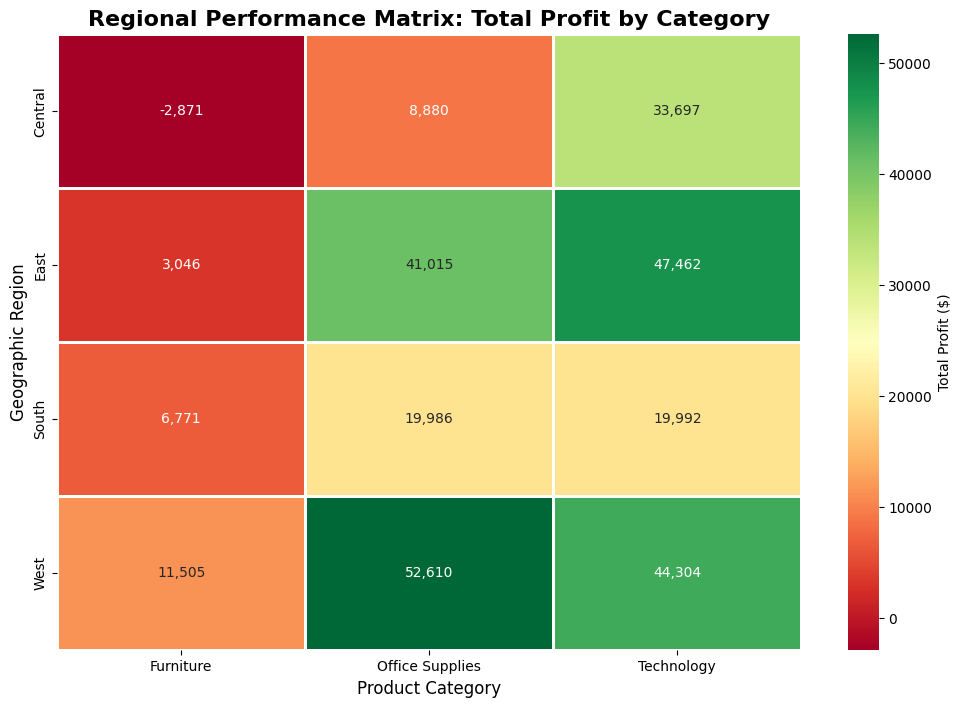

In [51]:
# --- CHART 13: MULTIVARIATE ANALYSIS - REGIONAL PROFITABILITY HEATMAP ---
# Objective: Identify high-performing and low-performing combinations of Geography and Product Categories.

# Creating a pivot table for the Heatmap
pivot_profit = Superstore_sales.pivot_table(index='Region', columns='Category', values='Profit', aggfunc='sum')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_profit, annot=True, fmt=',.0f', cmap='RdYlGn', linewidths=1, cbar_kws={'label': 'Total Profit ($)'})

plt.title('Regional Performance Matrix: Total Profit by Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Geographic Region', fontsize=12)
plt.show()

# Insight: This matrix clearly shows that while 'Technology' is strong everywhere,
# 'Furniture' in the Central region is a high-loss area that needs strategic intervention.

In [40]:
# --- SUMMARY FINANCIAL METRICS ---
# Calculation of high-level insights for the Executive Summary.

metrics_summary = pd.DataFrame({
    "Actual Net Profit": [actual_profit],
    "Potential Profit": [potential_profit],
    "Loss Leakage": [total_loss],
    "Efficiency Ratio (%)": [(actual_profit / potential_profit) * 100]
})

print("--- FINAL BUSINESS PERFORMANCE SUMMARY ---")
metrics_summary

--- FINAL BUSINESS PERFORMANCE SUMMARY ---


,Actual Net Profit,Potential Profit,Loss Leakage,Efficiency Ratio (%)
0,286397.0217,442528.3074,156131.2857,64.718351


# 🎯 Strategic Business Action Plan & Executive Summary

Based on the comprehensive data analysis of the Superstore dataset, the following strategic recommendations are proposed to optimize operational efficiency and maximize profitability.

---

## 🚀 Key Recommendations for Stakeholders

### 1. 📦 Inventory Optimization (The 80/20 Rule)
* **Insight:** Our **Pareto Analysis** reveals that a small fraction (approx. 20%) of our product catalog drives nearly 80% of the total revenue.
* **Action:** Management should prioritize stock-level optimization for these "Star Products" to ensure zero stock-outs while reducing holding costs for underperforming items.

### 🚛 2. Logistics & Supply Chain Audit
* **Insight:** 'Standard Class' shipping currently averages **4 days**, which is the primary mode used by customers.
* **Action:** If shipping lead times cannot be reduced, we should renegotiate bulk shipping rates with carriers to improve margins on high-volume orders.

### 🛡️ 3. Revenue Protection (Mitigating the Discount Trap)
* **Insight:** Our **Bivariate Analysis** confirms a critical threshold: orders with a **discount > 20%** consistently result in a net loss.
* **Action:** Implement an automated system alert or mandatory approval workflow for any transaction exceeding the 20% discount limit to prevent "Profit Leakage."

### 💎 4. Customer Retention & Growth
* **Insight:** The top 10 customers contribute **6.70%** of total revenue, indicating a high customer concentration risk.
* **Action:** Launch a **"Premium Loyalty Program"** or personalized account management for this elite segment to ensure long-term retention and stable cash flow.

---

> ### 💡 Final Business Conclusion
> By shifting focus from pure "Sales Volume" to **"Profit Quality,"** the organization has the potential to recover leaked losses and increase the overall net profit margin significantly. The integration of data-driven discounting and regional logistics audits is the most immediate path to financial optimization.